# 01 — Exploratory Data Analysis

Goal: understand the ingested NBA game data before building features. Each section maps to one EDA item from the project outline.

**Run:** `jupyter notebook` from the project root. Assumes `team_games` and `team_games_advanced` are populated.

## Setup

In [2]:
import sys
from pathlib import Path

# Make project root importable so we can use db.py
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from db import engine

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

## Load the joined dataset

One row per team per game, joining box-score and advanced stats.

In [3]:
query = """
SELECT g.*,
       a.off_rating, a.def_rating, a.net_rating,
       a.pace, a.ts_pct, a.efg_pct,
       a.ast_pct, a.ast_tov, a.oreb_pct, a.dreb_pct, a.tm_tov_pct, a.pie
FROM team_games g
LEFT JOIN team_games_advanced a USING (game_id, team_id)
WHERE g.season_type = 'Regular Season'
ORDER BY g.game_date, g.game_id, g.team_id
"""
df = pd.read_sql_query(query, engine)
df['game_date'] = pd.to_datetime(df['game_date'])
df['won'] = (df['wl'] == 'W').astype(int)
print(df.shape)
df.head()

(21498, 44)


,game_id,team_id,season,season_type,game_date,team_abbreviation,team_name,matchup,is_home,wl,min,pts,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,ftm,fta,ft_pct,oreb,dreb,reb,ast,stl,blk,tov,pf,plus_minus,ingested_at,off_rating,def_rating,net_rating,pace,ts_pct,efg_pct,ast_pct,ast_tov,oreb_pct,dreb_pct,tm_tov_pct,pie,won
0,0021600001,1610612739,2016-17,Regular Season,2016-10-25,CLE,Cleveland Cavaliers,CLE vs. NYK,True,W,240,117,45,94,0.479,13,35,0.371,14,19,0.737,11,40,51,31,12,5,15,22,29.0,2026-04-14 23:04:04.773123+00:00,115.8,87.1,28.7,101.0,0.572,0.548,0.689,None,0.353,0.729,0.149,0.703,1
1,0021600001,1610612752,2016-17,Regular Season,2016-10-25,NYK,New York Knicks,NYK @ CLE,False,L,240,88,32,87,0.368,9,27,0.333,15,20,0.750,13,29,42,17,6,6,18,22,-29.0,2026-04-14 23:04:04.773123+00:00,87.1,115.8,-28.7,101.0,0.459,0.420,0.531,None,0.271,0.647,0.178,0.297,0
2,0021600002,1610612757,2016-17,Regular Season,2016-10-25,POR,Portland Trail Blazers,POR vs. UTA,True,W,240,113,39,75,0.520,13,19,0.684,22,22,1.000,5,29,34,22,5,3,13,18,9.0,2026-04-14 23:04:04.773123+00:00,122.8,114.3,8.5,91.5,0.667,0.607,0.564,None,0.222,0.738,0.141,0.548,1
3,0021600002,1610612762,2016-17,Regular Season,2016-10-25,UTA,Utah Jazz,UTA @ POR,False,L,240,104,40,82,0.488,8,24,0.333,16,16,1.000,6,25,31,19,9,5,14,19,-9.0,2026-04-14 23:04:04.773123+00:00,114.3,122.8,-8.5,91.5,0.584,0.537,0.475,None,0.262,0.778,0.154,0.452,0
4,0021600003,1610612744,2016-17,Regular Season,2016-10-25,GSW,Golden State Warriors,GSW vs. SAS,True,L,240,100,40,85,0.471,7,33,0.212,13,18,0.722,8,27,35,24,11,6,16,19,-29.0,2026-04-14 23:04:04.773123+00:00,99.0,129.0,-30.0,100.5,0.538,0.512,0.600,None,0.208,0.528,0.158,0.400,0


In [4]:
# Per-season coverage check + flag the COVID seasons (per the outline's data-cleaning notes)
covid_seasons = {'2019-20', '2020-21'}
df['is_covid_season'] = df['season'].isin(covid_seasons)
df.groupby('season').agg(
    games=('game_id', 'nunique'),
    rows=('game_id', 'size'),
    home_share=('is_home', 'mean'),
    null_ortg=('off_rating', lambda s: s.isna().sum()),
)

,games,rows,home_share,null_ortg
season,,,,
2016-17,1230,2460,0.500000,0
2017-18,1230,2460,0.500000,0
2018-19,1230,2460,0.500000,0
2019-20,1059,2118,0.500000,0
2020-21,1080,2160,0.500000,0
2021-22,1230,2460,0.500000,0
2022-23,1230,2460,0.500000,0
2023-24,1230,2460,0.500000,0
2024-25,1230,2460,0.497967,0


## 1. Home-court win rate by season

Watch the bubble: 2019-20 and 2020-21 had neutral-site games and reduced/no fans. The outline calls this out as a feature corruption risk.

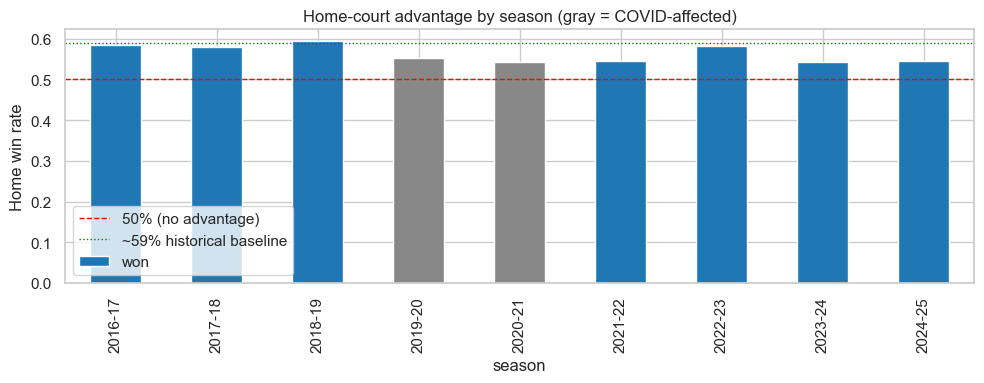

In [5]:
home_rates = df[df['is_home']].groupby('season')['won'].mean()
ax = home_rates.plot(kind='bar', figsize=(10, 4), color=['#888' if s in covid_seasons else '#1f77b4' for s in home_rates.index])
ax.axhline(0.5, color='red', ls='--', lw=1, label='50% (no advantage)')
ax.axhline(0.59, color='green', ls=':', lw=1, label='~59% historical baseline')
ax.set_ylabel('Home win rate')
ax.set_title('Home-court advantage by season (gray = COVID-affected)')
ax.legend()
plt.tight_layout()

## 2. Point differential distribution

Should be roughly normal, centered slightly above zero from the home team's perspective.

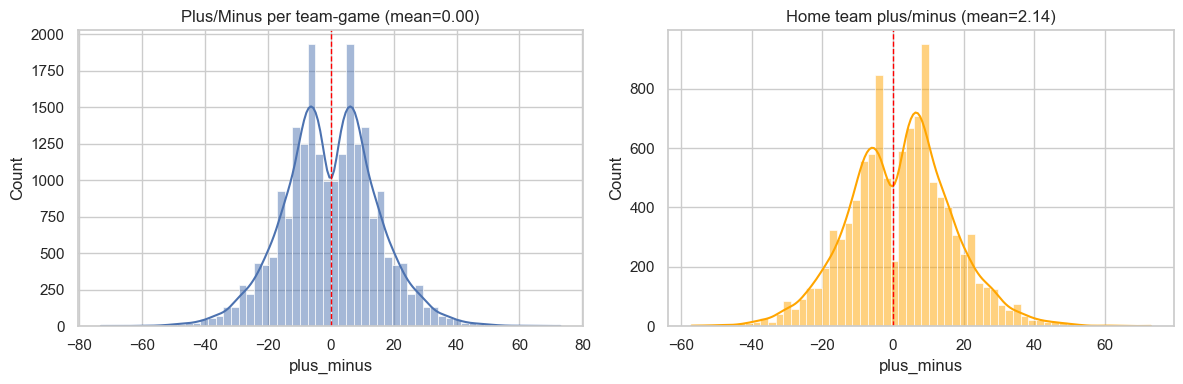

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['plus_minus'], bins=60, kde=True, ax=axes[0])
axes[0].axvline(0, color='red', ls='--', lw=1)
axes[0].set_title(f"Plus/Minus per team-game (mean={df['plus_minus'].mean():.2f})")

home_pm = df.loc[df['is_home'], 'plus_minus']
sns.histplot(home_pm, bins=60, kde=True, color='orange', ax=axes[1])
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_title(f"Home team plus/minus (mean={home_pm.mean():.2f})")
plt.tight_layout()

## 3. Days of rest

Compute rest as days since each team's previous game. Back-to-backs (rest=1) should show a measurable penalty.

In [7]:
df = df.sort_values(['team_id', 'game_date'])
df['days_rest'] = df.groupby(['team_id', 'season'])['game_date'].diff().dt.days
df['rest_bucket'] = pd.cut(df['days_rest'], bins=[0, 1, 2, 3, 4, 100], labels=['B2B (1)', '2', '3', '4', '5+'])

rest_table = df.groupby('rest_bucket', observed=True).agg(
    games=('won', 'size'),
    win_rate=('won', 'mean'),
    avg_pm=('plus_minus', 'mean'),
)
rest_table

,games,win_rate,avg_pm
rest_bucket,,,
B2B (1),3790,0.441425,-2.090765
2,13372,0.510096,0.400314
3,3096,0.523579,0.661822
4,551,0.535390,1.119782
5+,397,0.483627,-0.370277


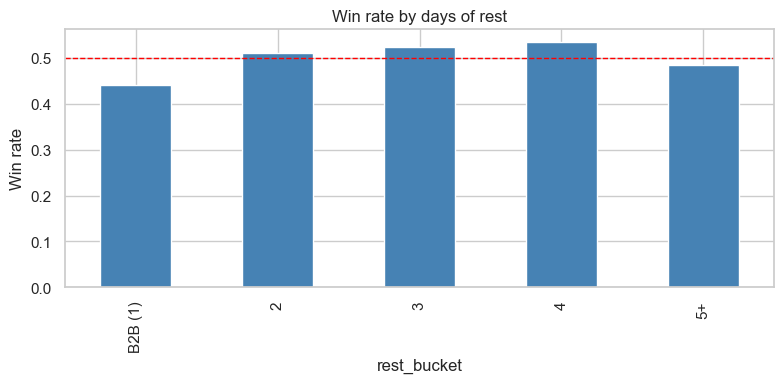

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
rest_table['win_rate'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.5, color='red', ls='--', lw=1)
ax.set_ylabel('Win rate')
ax.set_title('Win rate by days of rest')
plt.tight_layout()

## 4. Win rate by month

Outline hypothesis: teams struggle in November, peak in March/April.

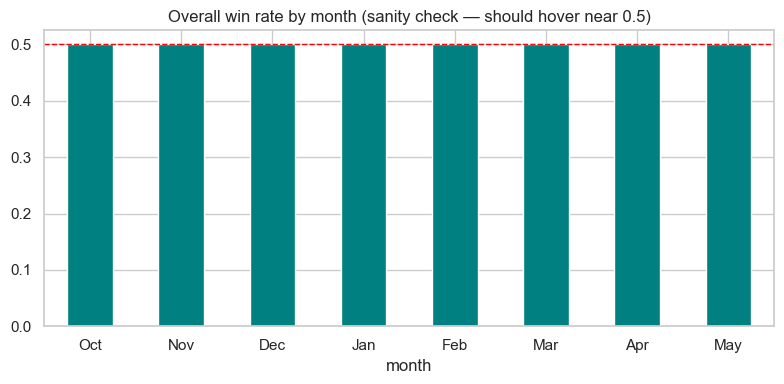

In [9]:
df['month'] = df['game_date'].dt.month
month_order = [10, 11, 12, 1, 2, 3, 4, 5, 6]  # NBA season runs Oct–Jun
monthly = df.groupby('month')['won'].mean().reindex(month_order).dropna()
ax = monthly.plot(kind='bar', figsize=(8, 4), color='teal')
ax.axhline(0.5, color='red', ls='--', lw=1)
ax.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun'][:len(monthly)], rotation=0)
ax.set_title('Overall win rate by month (sanity check — should hover near 0.5)')
plt.tight_layout()

## 5. Net Rating vs. season win rate

Net Rating is the single best predictor of team quality. The relationship should be tight and roughly linear.

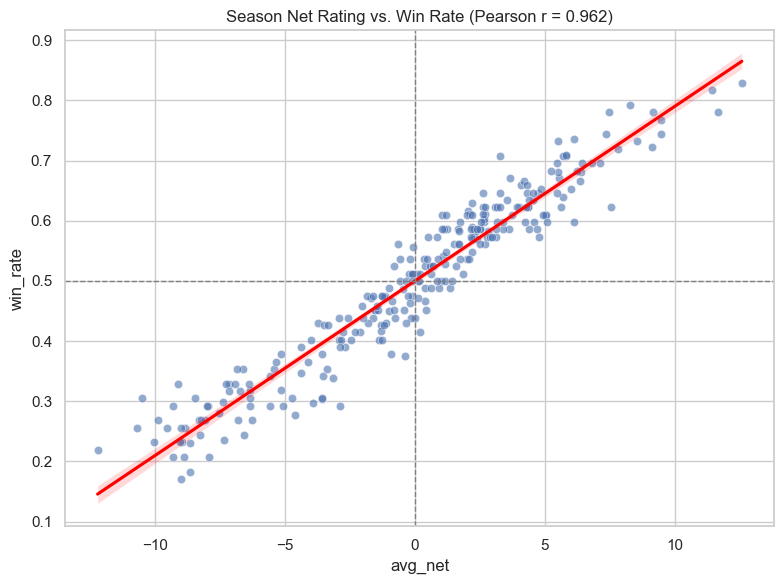

In [10]:
team_season = df.groupby(['season', 'team_abbreviation']).agg(
    win_rate=('won', 'mean'),
    avg_net=('net_rating', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=team_season, x='avg_net', y='win_rate', alpha=0.6, ax=ax)
sns.regplot(data=team_season, x='avg_net', y='win_rate', scatter=False, color='red', ax=ax)
ax.axhline(0.5, color='gray', ls='--', lw=1)
ax.axvline(0, color='gray', ls='--', lw=1)
corr = team_season[['avg_net', 'win_rate']].corr().iloc[0, 1]
ax.set_title(f'Season Net Rating vs. Win Rate (Pearson r = {corr:.3f})')
plt.tight_layout()

## 6. Feature correlation heatmap

Identify redundant candidate features before modeling. High-correlation pairs (e.g. ts_pct/efg_pct) tell you not to include both.

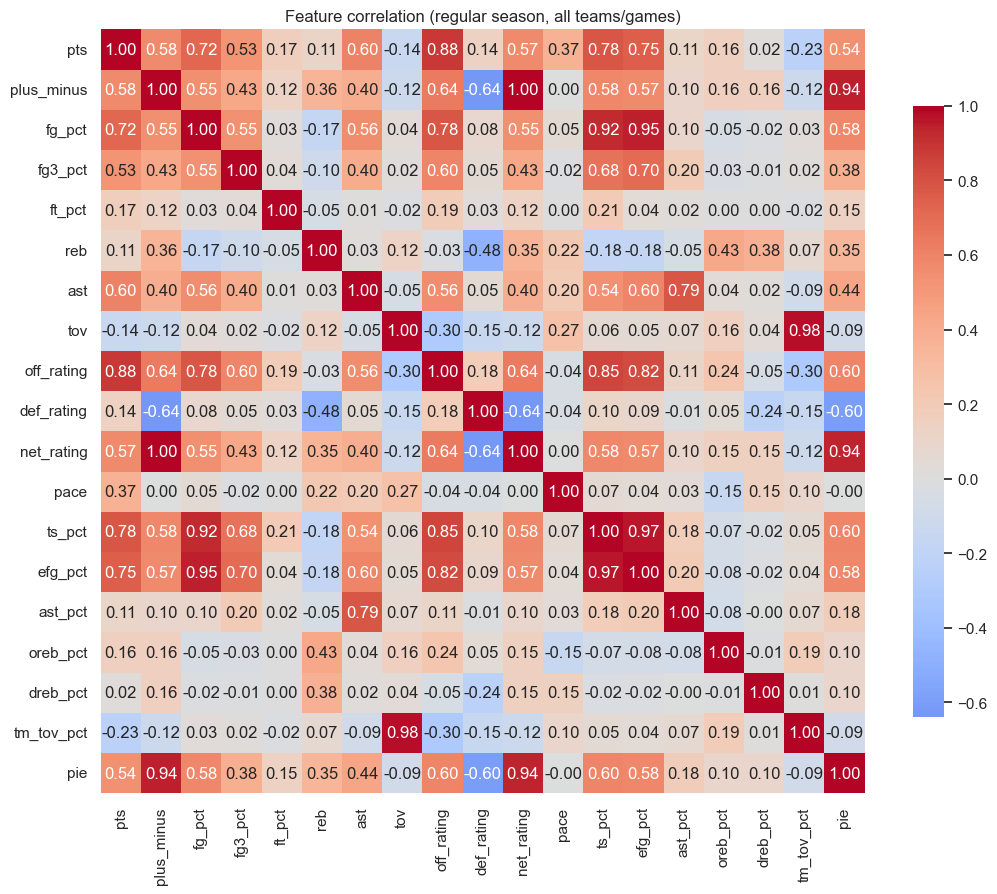

In [11]:
feat_cols = ['pts', 'plus_minus', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov',
             'off_rating', 'def_rating', 'net_rating', 'pace', 'ts_pct', 'efg_pct',
             'ast_pct', 'oreb_pct', 'dreb_pct', 'tm_tov_pct', 'pie']
corr = df[feat_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature correlation (regular season, all teams/games)')
plt.tight_layout()

## 7. Neutral-site games (data-quality check)

Surface the 5 neutral-site games per season we identified during ingestion. These need an `is_neutral` flag in the feature layer so they don't poison home/away features.

In [12]:
neutral = (
    df.groupby('game_id')
      .filter(lambda g: (~g['is_home']).all())
      .sort_values(['game_date', 'game_id'])
      [['season', 'game_date', 'team_abbreviation', 'matchup']]
)
print(f'Neutral-site games (both teams away): {neutral["game_date"].nunique()} dates, {len(neutral)//2} games')
neutral.head(20)

Neutral-site games (both teams away): 4 dates, 5 games


,season,game_date,team_abbreviation,matchup
19210,2024-25,2024-11-02,MIA,MIA @ WAS
19211,2024-25,2024-11-02,WAS,WAS @ MIA
19786,2024-25,2024-12-14,ATL,ATL @ MIL
19787,2024-25,2024-12-14,MIL,MIL @ ATL
19788,2024-25,2024-12-14,HOU,HOU @ OKC
19789,2024-25,2024-12-14,OKC,OKC @ HOU
20328,2024-25,2025-01-23,IND,IND @ SAS
20329,2024-25,2025-01-23,SAS,SAS @ IND
20352,2024-25,2025-01-25,IND,IND @ SAS
20353,2024-25,2025-01-25,SAS,SAS @ IND


## Takeaways → feature engineering

Notes to carry into `src/features/`:
- Home advantage is real but season-dependent → flag COVID seasons or downweight them in training.
- Back-to-backs show a measurable penalty → keep `b2b` and `rest_diff` features.
- Net Rating ↔ win rate correlation is the upper bound on what season-aggregate features can buy you. Per-game rolling Net Rating with `.shift(1)` is the model-ready version.
- TS%, eFG%, and FG% are highly correlated → pick one for tree models; logistic regression cares more.
- Neutral-site games need an `is_neutral` flag derived from `is_home == False` for both rows of a game.